# 📊 Overview of Dataset

This dataset contains **4242 images of flowers** 🌸.
The collection is based on data from **Flickr, Google Images, and Yandex Images**.

You can use this dataset to **recognize plants from photos**.

The pictures are divided into **five classes**:
- 🌼 Chamomile
- 🌷 Tulip
- 🌹 Rose
- 🌻 Sunflower
- 🌸 Dandelion

Each class contains about **800 photos**.

⚠️ Note: The photos are not high resolution (≈ **320×240 px**) and are not reduced to a single size, meaning they have **different proportions**.


In [2]:
# Importing necessary libraries
import numpy as np
import os
import glob
import glob
import matplotlib.pyplot as plt
import random
import cv2

# Counting images in each class

In [3]:
# ---------------------------
# Setup dataset path
# ---------------------------

DATASET_DIR = '../data/flowers'
classes = os.listdir(DATASET_DIR)
print(f'Classes: {classes}')

# ---------------------------
# Counting images in each class
# ---------------------------

class_counts= {cls: len(list(glob.iglob(os.path.join(DATASET_DIR, cls, '*.jpg')))) for cls in classes}

print("\nNumber of images per class:")

for cls, num in class_counts.items():
    print(f'{cls}: {num}')


Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Number of images per class:
daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984


# Visualization

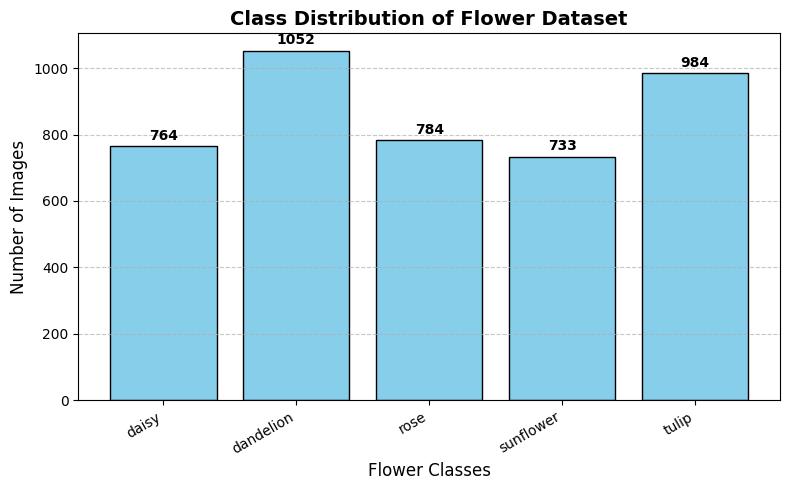

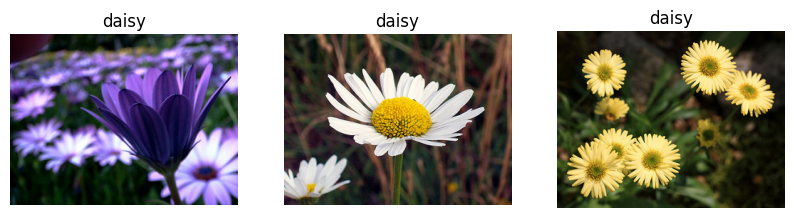

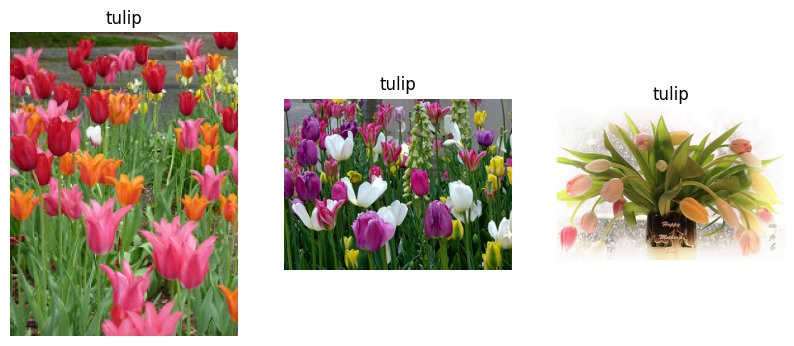

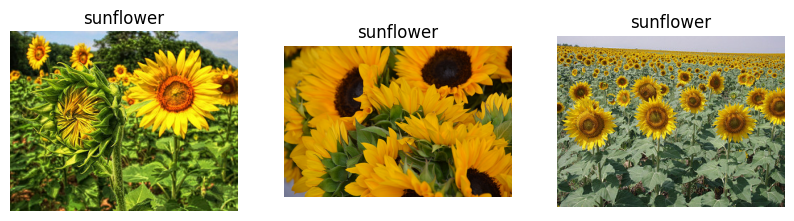

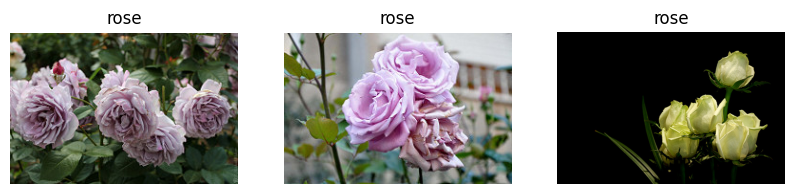

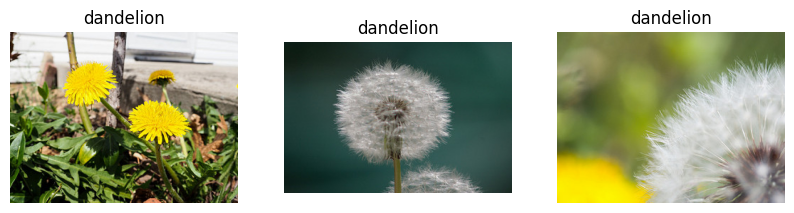

In [4]:
# ---------------------------
# Plot distribution
# ---------------------------

plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color="skyblue", edgecolor="black")

plt.title("Class Distribution of Flower Dataset", fontsize=14, weight="bold")
plt.xlabel("Flower Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(height),
             ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()

# ---------------------------
# Sample Visualization
# ---------------------------
for class_name in random.sample(list(class_counts.keys()), 5):
    class_path = os.path.join(DATASET_DIR, class_name)
    sample_images = random.sample(os.listdir(class_path), 3)
    fig, axes = plt.subplots(1, 3, figsize=(10,4))
    for i, img_name in enumerate(sample_images):
        img = cv2.imread(os.path.join(class_path, img_name))
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis("off")
    plt.show()


In [15]:
# ---------------------------
# Processing Data
# ---------------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
images, labels =[], []

# Load dataset
for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        images.append(img)
        labels.append(class_name)

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)


# Normalize images and convert to numpy
images= np.array(images, dtype="float32") / 225.0
mean = np.mean(images, axis= (0, 1, 2), keepdims=True)
std = np.std(images, axis= (0, 1, 2), keepdims=True)

images = (images - mean) / (std + 1e-7)

# Split train, val, test
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.1, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

print(f'Number of training images: {len(X_train)}')
print(f'Number of validation images: {len(X_val)}')
print(f'Number of testing images: {len(X_test)}')


Number of training images: 3399
Number of validation images: 486
Number of testing images: 432


# Feature Extraction